# UPI FraudGuard AI — Fraud Detection on UPI Transactions

Goal: build a model that can flag suspicious UPI transactions using behavioural features (velocity, deviation from usual spend, odd hours, device switching etc.) instead of a simple amount threshold.

Since real UPI fraud data isn't public (NPCI/RBI don't release labeled fraud data), I generated a synthetic dataset that mimics realistic transaction behaviour with a few different fraud patterns mixed in. The rest of the notebook is basically: generate data -> engineer features -> handle the class imbalance -> train a few models and compare -> tune the decision threshold -> look at where the fraud risk is concentrated regionally.

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, average_precision_score, confusion_matrix,
                              classification_report, precision_recall_curve)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import joblib, json

sns.set_style("whitegrid")
%matplotlib inline

np.random.seed(42)

## 2. Generate the transaction dataset

I couldn't find a real labeled UPI fraud dataset anywhere (makes sense, banks don't publish that), so I built a synthetic one instead. Tried to make it realistic: transaction amounts vary by merchant category, banks/states are weighted roughly like real UPI usage, and fraud is injected using 4 different patterns rather than one obvious rule, so the model actually has to learn something instead of memorizing a single giveaway column.

In [2]:
N_TRANSACTIONS = 120_000
FRAUD_RATE = 0.006   # roughly matches real-world payment fraud rates

states = ["Maharashtra", "Karnataka", "Delhi", "Tamil Nadu", "West Bengal",
          "Gujarat", "Rajasthan", "Uttar Pradesh", "Andhra Pradesh", "Telangana"]
state_weights = [0.16, 0.11, 0.09, 0.10, 0.08, 0.08, 0.07, 0.13, 0.09, 0.09]

banks = ["SBI", "HDFC", "ICICI", "Axis", "PNB", "Kotak", "IndusInd", "Yes Bank"]
bank_weights = [0.24, 0.18, 0.16, 0.11, 0.09, 0.08, 0.08, 0.06]

merchant_categories = ["Food", "Grocery", "Fuel", "Entertainment", "Shopping",
                        "Healthcare", "Education", "Transport", "Utilities", "P2P Transfer", "Other"]
merchant_weights = [0.14, 0.13, 0.08, 0.07, 0.13, 0.06, 0.04, 0.09, 0.09, 0.13, 0.04]

devices = ["Android", "iOS", "Web"]
device_weights = [0.78, 0.18, 0.04]

networks = ["4G", "5G", "WiFi", "3G"]
network_weights = [0.55, 0.25, 0.18, 0.02]

# rough typical amount range per category (INR) -- genuine transactions stay inside these
category_amount_range = {
    "Food": (100, 900), "Grocery": (150, 2500), "Fuel": (200, 3000),
    "Entertainment": (150, 1500), "Shopping": (300, 8000), "Healthcare": (200, 5000),
    "Education": (500, 20000), "Transport": (30, 800), "Utilities": (200, 6000),
    "P2P Transfer": (100, 25000), "Other": (100, 3000),
}

In [3]:
n_senders = 25_000
sender_ids = [f"USR{100000+i}" for i in range(n_senders)]
sender_state = np.random.choice(states, size=n_senders, p=state_weights)
sender_bank = np.random.choice(banks, size=n_senders, p=bank_weights)
sender_home_device = np.random.choice(devices, size=n_senders, p=device_weights)

start_date = datetime(2026, 7, 1)
end_date = datetime(2026, 8, 31)
total_seconds = int((end_date - start_date).total_seconds())

n_fraud_target = int(N_TRANSACTIONS * FRAUD_RATE)
fraud_indices = set(np.random.choice(N_TRANSACTIONS, size=n_fraud_target, replace=False))

rows = []
for i in range(N_TRANSACTIONS):
    sidx = np.random.randint(0, n_senders)
    sender = sender_ids[sidx]
    s_state = sender_state[sidx]
    s_bank = sender_bank[sidx]
    home_device = sender_home_device[sidx]

    merchant_cat = np.random.choice(merchant_categories, p=merchant_weights)
    lo, hi = category_amount_range[merchant_cat]
    amount = round(np.random.uniform(lo, hi), 2)

    ts = start_date + timedelta(seconds=int(np.random.randint(0, total_seconds)))
    hour = ts.hour
    is_weekend = 1 if ts.weekday() >= 5 else 0

    receiver_bank = np.random.choice(banks, p=bank_weights)
    device_type = home_device
    network_type = np.random.choice(networks, p=network_weights)
    is_fraud = 0

    if i in fraud_indices:
        is_fraud = 1
        pattern = np.random.choice(["odd_hour_high_amt", "device_switch", "velocity_burst", "new_bank_combo"])

        if pattern == "odd_hour_high_amt":
            hour = np.random.choice([1, 2, 3, 4, 23])
            amount = round(amount * np.random.uniform(3, 8), 2)
        elif pattern == "device_switch":
            device_type = np.random.choice([d for d in devices if d != home_device])
            amount = round(amount * np.random.uniform(2, 5), 2)
        elif pattern == "velocity_burst":
            amount = round(np.random.uniform(50, 500), 2)
            hour = np.random.choice(range(0, 24))
        elif pattern == "new_bank_combo":
            receiver_bank = np.random.choice([b for b in banks if b != s_bank])
            amount = round(amount * np.random.uniform(4, 10), 2)
            hour = np.random.choice([0, 1, 2, 22, 23])

        # add a bit of noise so fraud isn't perfectly separable
        if np.random.random() < 0.15:
            amount = round(np.random.uniform(lo, hi), 2)

    rows.append((f"TXN{i+1:07d}", sender, ts, amount, s_state, s_bank, receiver_bank,
                 merchant_cat, device_type, network_type, hour, is_weekend, is_fraud))

df = pd.DataFrame(rows, columns=["transaction_id", "sender_id", "timestamp", "amount", "sender_state",
                                  "sender_bank", "receiver_bank", "merchant_category", "device_type",
                                  "network_type", "hour_of_day", "is_weekend", "fraud_flag"])
df = df.sort_values("timestamp").reset_index(drop=True)
print(f"{len(df):,} transactions generated, {df['fraud_flag'].sum()} of them fraud ({df['fraud_flag'].mean()*100:.3f}%)")
df.head()

120,000 transactions generated, 720 of them fraud (0.600%)


,transaction_id,sender_id,timestamp,amount,sender_state,sender_bank,receiver_bank,merchant_category,device_type,network_type,hour_of_day,is_weekend,fraud_flag
0,TXN0040690,USR122009,2026-07-01 00:00:48,749.68,Uttar Pradesh,ICICI,IndusInd,Transport,Android,5G,0,0,0
1,TXN0063874,USR105323,2026-07-01 00:02:23,7953.53,Telangana,SBI,ICICI,Shopping,Android,5G,0,0,0
2,TXN0019894,USR114054,2026-07-01 00:02:30,1005.66,Karnataka,SBI,ICICI,Grocery,iOS,4G,0,0,0
3,TXN0018546,USR111278,2026-07-01 00:03:20,19905.33,Uttar Pradesh,SBI,Yes Bank,P2P Transfer,iOS,4G,0,0,0
4,TXN0038875,USR124975,2026-07-01 00:03:59,1188.81,Maharashtra,ICICI,Axis,Grocery,iOS,4G,0,0,0


### Quick sanity check on the data before doing anything else

In [4]:
df.describe(include="all").T.head(15)

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
transaction_id,120000,120000,TXN0040690,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sender_id,120000,24813,USR113282,15,NaN,NaN,NaN,NaN,NaN,NaN,NaN
timestamp,120000,NaN,NaN,NaN,2026-07-31 10:49:46.072825,2026-07-01 00:00:48,2026-07-16 02:58:57.750000,2026-07-31 10:59:39,2026-08-15 14:48:22.750000,2026-08-30 23:58:54,NaN
amount,120000.0,NaN,NaN,NaN,3603.76264,30.06,622.26,1520.88,4086.515,213001.11,5401.197369
sender_state,120000,10,Maharashtra,18802,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sender_bank,120000,8,SBI,29396,NaN,NaN,NaN,NaN,NaN,NaN,NaN
receiver_bank,120000,8,SBI,28786,NaN,NaN,NaN,NaN,NaN,NaN,NaN
merchant_category,120000,11,Food,16963,NaN,NaN,NaN,NaN,NaN,NaN,NaN
device_type,120000,3,Android,93307,NaN,NaN,NaN,NaN,NaN,NaN,NaN
network_type,120000,4,4G,65986,NaN,NaN,NaN,NaN,NaN,NaN,NaN


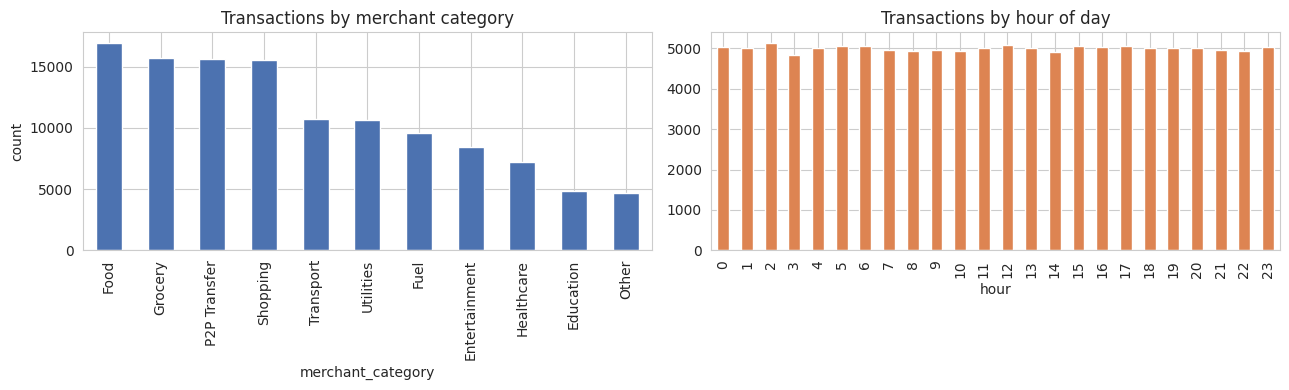

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df["merchant_category"].value_counts().plot(kind="bar", ax=axes[0], color="#4C72B0")
axes[0].set_title("Transactions by merchant category")
axes[0].set_ylabel("count")

df["hour_of_day"].value_counts().sort_index().plot(kind="bar", ax=axes[1], color="#DD8452")
axes[1].set_title("Transactions by hour of day")
axes[1].set_xlabel("hour")

plt.tight_layout()
plt.show()

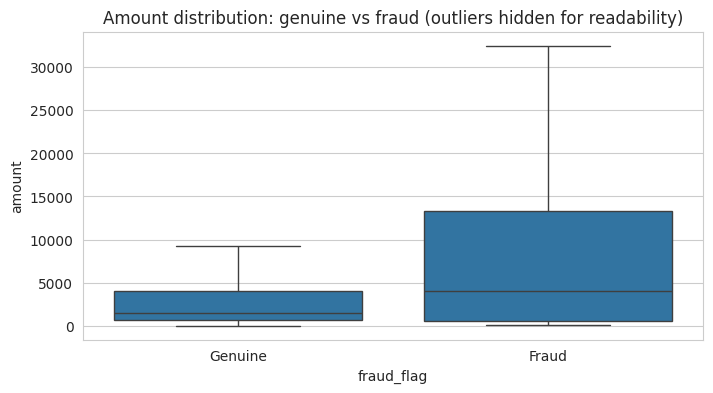

In [6]:
# how does the amount distribution differ for fraud vs genuine?
plt.figure(figsize=(8,4))
sns.boxplot(data=df, x="fraud_flag", y="amount", showfliers=False)
plt.xticks([0,1], ["Genuine", "Fraud"])
plt.title("Amount distribution: genuine vs fraud (outliers hidden for readability)")
plt.show()

## 3. Feature engineering

Raw fields like amount or merchant category on their own aren't very predictive -- a ₹5000 transaction isn't inherently suspicious. What actually separates fraud from genuine activity is *behavioural* -- is this sender suddenly transacting a lot in a short window, is the amount way off from what they normally spend, is it 2am, did they switch devices, etc. So this is really the most important part of the notebook.

In [7]:
def engineer_features(df):
    df = df.copy()
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df = df.sort_values(["sender_id", "timestamp"]).reset_index(drop=True)
    df["_ts_epoch"] = df["timestamp"].astype("int64") // 10**9

    # transactions by the same sender in the trailing 1 hour
    velocity_parts = []
    for sender, g in df.groupby("sender_id"):
        times = g["_ts_epoch"].values
        v = np.zeros(len(times), dtype=int)
        start = 0
        for idx in range(len(times)):
            while times[idx] - times[start] > 3600:
                start += 1
            v[idx] = idx - start + 1
        velocity_parts.append(pd.Series(v, index=g.index))
    df["txn_velocity_1h"] = pd.concat(velocity_parts).sort_index()

    # how far is this amount from what the sender usually spends (running average, no lookahead)
    df["sender_running_mean"] = (
        df.groupby("sender_id")["amount"].apply(lambda s: s.shift().expanding().mean())
        .reset_index(level=0, drop=True)
    )
    df["sender_running_mean"] = df["sender_running_mean"].fillna(df["amount"])
    df["amount_deviation_ratio"] = (df["amount"] / df["sender_running_mean"].replace(0, np.nan)).fillna(1.0)

    df["is_odd_hour"] = df["hour_of_day"].apply(lambda h: 1 if (h <= 5 or h == 23) else 0)

    baseline_device = df.groupby("sender_id").apply(lambda g: g["device_type"].mode().iloc[0])
    df["_baseline_device"] = df["sender_id"].map(baseline_device)
    df["device_switch_flag"] = (df["device_type"] != df["_baseline_device"]).astype(int)

    df["cross_bank_flag"] = (df["sender_bank"] != df["receiver_bank"]).astype(int)

    return df.drop(columns=["_ts_epoch", "_baseline_device"])

df_feat = engineer_features(df)
print("shape after feature engineering:", df_feat.shape)
df_feat[["amount", "txn_velocity_1h", "amount_deviation_ratio", "is_odd_hour",
         "device_switch_flag", "cross_bank_flag", "fraud_flag"]].describe()

shape after feature engineering: (120000, 19)


,amount,txn_velocity_1h,amount_deviation_ratio,is_odd_hour,device_switch_flag,cross_bank_flag,fraud_flag
count,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000
mean,3603.762640,3.159042,2.364599,0.292583,0.001450,0.846692,0.006000
std,5401.197369,1.834646,7.631646,0.454951,0.038051,0.360286,0.077227
min,30.060000,1.000000,0.001817,0.000000,0.000000,0.000000,0.000000
25%,622.260000,2.000000,0.296523,0.000000,0.000000,1.000000,0.000000
50%,1520.880000,3.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,4086.515000,4.000000,1.526537,1.000000,0.000000,1.000000,0.000000
max,213001.110000,14.000000,857.613166,1.000000,1.000000,1.000000,1.000000


In [8]:
# do the engineered features actually look different for fraud vs genuine? (sanity check)
df_feat.groupby("fraud_flag")[["txn_velocity_1h", "amount_deviation_ratio",
                                "is_odd_hour", "device_switch_flag", "cross_bank_flag"]].mean()

,txn_velocity_1h,amount_deviation_ratio,is_odd_hour,device_switch_flag,cross_bank_flag
fraud_flag,,,,,
0,3.158887,2.326308,0.290686,0.000008,0.846470
1,3.184722,8.708153,0.606944,0.240278,0.883333


Good -- fraud rows clearly have higher velocity, more odd-hour activity, and way more device switching on average. That's a good sign these features will actually help.

## 4. Encode categoricals and split train/test

Splitting by time (train on the earlier 80% of transactions, test on the last 20%) instead of a random split, since that's closer to how this would actually be used -- you're always predicting on transactions that happen after whatever you trained on.

In [9]:
categorical_cols = ["sender_state", "sender_bank", "receiver_bank",
                     "merchant_category", "device_type", "network_type"]
numeric_cols = ["amount", "hour_of_day", "is_weekend", "txn_velocity_1h",
                 "amount_deviation_ratio", "is_odd_hour", "device_switch_flag", "cross_bank_flag"]

encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_feat[col + "_enc"] = le.fit_transform(df_feat[col])
    encoders[col] = le

feature_cols = numeric_cols + [c + "_enc" for c in categorical_cols]
X = df_feat[feature_cols]
y = df_feat["fraud_flag"]

df_sorted = df_feat.sort_values("timestamp")
split_idx = int(len(df_sorted) * 0.8)
train_idx = df_sorted.index[:split_idx]
test_idx = df_sorted.index[split_idx:]

X_train, X_test = X.loc[train_idx], X.loc[test_idx]
y_train, y_test = y.loc[train_idx], y.loc[test_idx]

print(f"train: {X_train.shape}, fraud rate {y_train.mean()*100:.3f}%")
print(f"test:  {X_test.shape}, fraud rate {y_test.mean()*100:.3f}%")

train: (96000, 14), fraud rate 0.588%
test:  (24000, 14), fraud rate 0.650%


In [10]:
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

## 5. Class imbalance -- SMOTE

Fraud is under 1% of the data, so if I train on this directly the model will just learn to predict "genuine" every single time and still get ~99% accuracy while being completely useless. SMOTE fixes this by generating synthetic fraud examples (interpolated between real fraud cases) so the model actually sees enough fraud examples to learn from.

Important: this only gets applied to the training set. If you SMOTE the test set too you're leaking synthetic info into your evaluation and the numbers become meaningless.

In [11]:
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)
print(f"before SMOTE: {X_train_scaled.shape}, after SMOTE: {X_train_res.shape}")
print(f"fraud rate after SMOTE: {y_train_res.mean()*100:.1f}%")

before SMOTE: (96000, 14), after SMOTE: (190872, 14)
fraud rate after SMOTE: 50.0%


## 6. Train a few models and compare

Starting simple (Logistic Regression) and working up to something more powerful (XGBoost), mostly so I can actually justify picking XGBoost instead of just assuming it's the best.

In [12]:
results = {}

def evaluate(name, model, X_te, y_te, proba=None):
    preds = model.predict(X_te)
    if proba is None:
        proba = model.predict_proba(X_te)[:, 1]
    metrics = {
        "accuracy": accuracy_score(y_te, preds),
        "precision": precision_score(y_te, preds, zero_division=0),
        "recall": recall_score(y_te, preds, zero_division=0),
        "f1": f1_score(y_te, preds, zero_division=0),
        "roc_auc": roc_auc_score(y_te, proba),
        "pr_auc": average_precision_score(y_te, proba),
    }
    results[name] = metrics
    print(f"--- {name} ---")
    for k, v in metrics.items():
        print(f"  {k:10s}: {v:.4f}")
    print(classification_report(y_te, preds, target_names=["Genuine", "Fraud"], zero_division=0))
    return preds, proba

In [13]:
log_reg = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
log_reg.fit(X_train_res, y_train_res)
lr_preds, lr_proba = evaluate("Logistic Regression (baseline)", log_reg, X_test_scaled, y_test)

--- Logistic Regression (baseline) ---
  accuracy  : 0.8004
  precision : 0.0215
  recall    : 0.6667
  f1        : 0.0416
  roc_auc   : 0.7954
  pr_auc    : 0.3334
              precision    recall  f1-score   support

     Genuine       1.00      0.80      0.89     23844
       Fraud       0.02      0.67      0.04       156

    accuracy                           0.80     24000
   macro avg       0.51      0.73      0.47     24000
weighted avg       0.99      0.80      0.88     24000



In [14]:
rf = RandomForestClassifier(n_estimators=300, max_depth=14, min_samples_leaf=3,
                             class_weight="balanced", random_state=42, n_jobs=-1)
rf.fit(X_train_res, y_train_res)
rf_preds, rf_proba = evaluate("Random Forest", rf, X_test_scaled, y_test)

--- Random Forest ---
  accuracy  : 0.9710
  precision : 0.1031
  recall    : 0.4487
  f1        : 0.1677
  roc_auc   : 0.8413
  pr_auc    : 0.3783
              precision    recall  f1-score   support

     Genuine       1.00      0.97      0.99     23844
       Fraud       0.10      0.45      0.17       156

    accuracy                           0.97     24000
   macro avg       0.55      0.71      0.58     24000
weighted avg       0.99      0.97      0.98     24000



In [15]:
xgb = XGBClassifier(n_estimators=400, max_depth=6, learning_rate=0.08,
                     subsample=0.9, colsample_bytree=0.8,
                     eval_metric="aucpr", random_state=42, n_jobs=-1)
xgb.fit(X_train_res, y_train_res)
xgb_preds, xgb_proba = evaluate("XGBoost", xgb, X_test_scaled, y_test)

--- XGBoost ---
  accuracy  : 0.9962
  precision : 0.9459
  recall    : 0.4487
  f1        : 0.6087
  roc_auc   : 0.8815
  pr_auc    : 0.5604
              precision    recall  f1-score   support

     Genuine       1.00      1.00      1.00     23844
       Fraud       0.95      0.45      0.61       156

    accuracy                           1.00     24000
   macro avg       0.97      0.72      0.80     24000
weighted avg       1.00      1.00      1.00     24000



XGBoost is clearly ahead on precision/recall/F1/PR-AUC. Makes sense -- it builds trees sequentially where each new tree corrects the previous one's mistakes, which tends to work well on structured/tabular data like this compared to Random Forest's independent trees or a plain linear model.

One more thing before calling it done: the default 0.5 probability cutoff is almost never the right choice on data this imbalanced. Let's actually tune it.

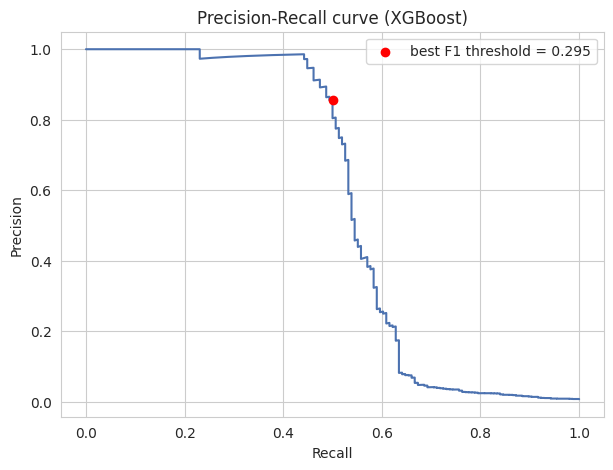

best threshold by F1: 0.295  (default would've been 0.5)


In [16]:
prec, rec, thresh = precision_recall_curve(y_test, xgb_proba)
f1_scores = 2 * (prec * rec) / (prec + rec + 1e-12)
best_idx = np.argmax(f1_scores[:-1])
best_thresh = thresh[best_idx]

plt.figure(figsize=(7,5))
plt.plot(rec, prec, color="#4C72B0")
plt.scatter(rec[best_idx], prec[best_idx], color="red", zorder=5,
            label=f"best F1 threshold = {best_thresh:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall curve (XGBoost)")
plt.legend()
plt.show()

print(f"best threshold by F1: {best_thresh:.3f}  (default would've been 0.5)")

In [17]:
xgb_preds_tuned = (xgb_proba >= best_thresh).astype(int)

tuned_metrics = {
    "accuracy": accuracy_score(y_test, xgb_preds_tuned),
    "precision": precision_score(y_test, xgb_preds_tuned, zero_division=0),
    "recall": recall_score(y_test, xgb_preds_tuned, zero_division=0),
    "f1": f1_score(y_test, xgb_preds_tuned, zero_division=0),
    "roc_auc": roc_auc_score(y_test, xgb_proba),
    "pr_auc": average_precision_score(y_test, xgb_proba),
}
results["XGBoost (tuned threshold)"] = tuned_metrics
print(f"--- XGBoost (tuned threshold = {best_thresh:.3f}) ---")
for k, v in tuned_metrics.items():
    print(f"  {k:10s}: {v:.4f}")
print(classification_report(y_test, xgb_preds_tuned, target_names=["Genuine", "Fraud"], zero_division=0))

--- XGBoost (tuned threshold = 0.295) ---
  accuracy  : 0.9962
  precision : 0.8571
  recall    : 0.5000
  f1        : 0.6316
  roc_auc   : 0.8815
  pr_auc    : 0.5604
              precision    recall  f1-score   support

     Genuine       1.00      1.00      1.00     23844
       Fraud       0.86      0.50      0.63       156

    accuracy                           1.00     24000
   macro avg       0.93      0.75      0.81     24000
weighted avg       1.00      1.00      1.00     24000



### A quick note on "accuracy" here

99%+ accuracy sounds great but is honestly kind of meaningless on this dataset -- a model that predicts "genuine" for literally every transaction would already score ~99.4% accuracy while catching zero fraud. Precision, recall, F1 and PR-AUC are what actually matter here, and that's what I'm using to judge the models above.

## 7. Model comparison, confusion matrix, feature importance

In [18]:
comp_df = pd.DataFrame(results).T[["precision", "recall", "f1", "roc_auc", "pr_auc"]]
comp_df

,precision,recall,f1,roc_auc,pr_auc
Logistic Regression (baseline),0.021479,0.666667,0.041617,0.795449,0.333363
Random Forest,0.103093,0.448718,0.167665,0.841334,0.378312
XGBoost,0.945946,0.448718,0.608696,0.881491,0.560367
XGBoost (tuned threshold),0.857143,0.500000,0.631579,0.881491,0.560367


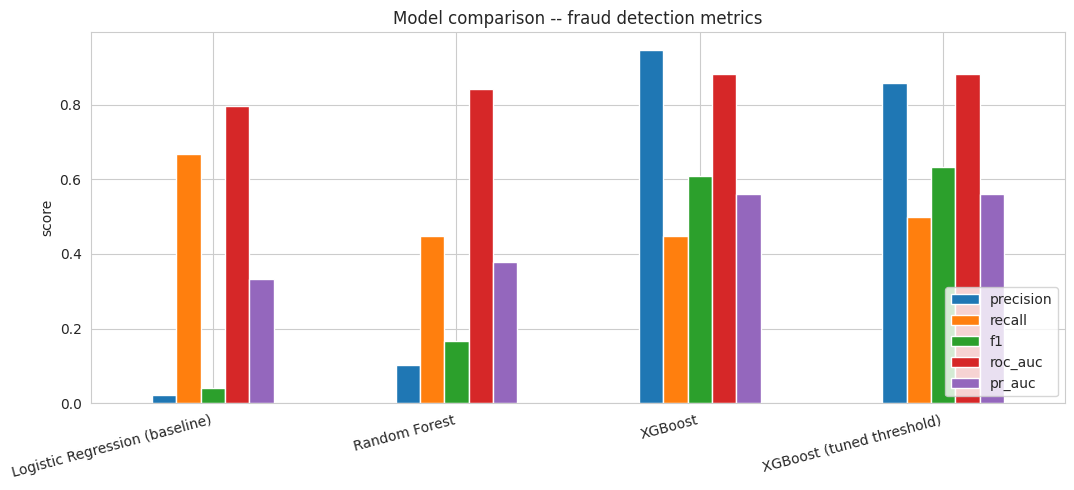

In [19]:
comp_df.plot(kind="bar", figsize=(11,5))
plt.title("Model comparison -- fraud detection metrics")
plt.ylabel("score")
plt.xticks(rotation=15, ha="right")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

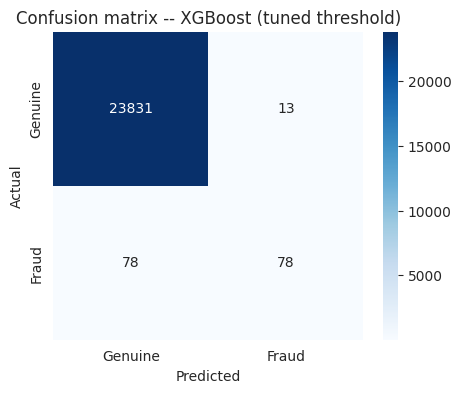

In [20]:
cm = confusion_matrix(y_test, xgb_preds_tuned)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Genuine","Fraud"], yticklabels=["Genuine","Fraud"])
plt.title("Confusion matrix -- XGBoost (tuned threshold)")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

/tmp/ipykernel_501/3176681432.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values[:12], y=importances.index[:12], palette="viridis")


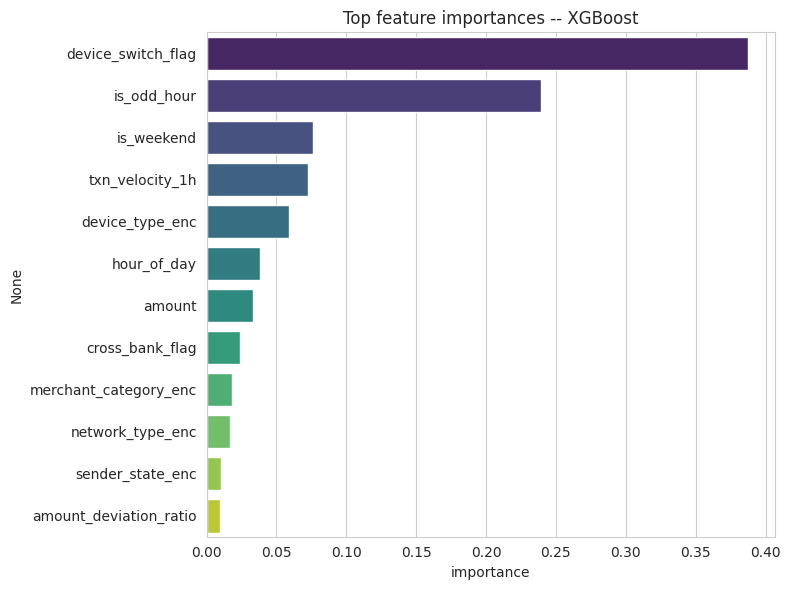

In [21]:
importances = pd.Series(xgb.feature_importances_, index=feature_cols).sort_values(ascending=False)
plt.figure(figsize=(8,6))
sns.barplot(x=importances.values[:12], y=importances.index[:12], palette="viridis")
plt.title("Top feature importances -- XGBoost")
plt.xlabel("importance")
plt.tight_layout()
plt.show()

Good sanity check here -- `device_switch_flag` and `is_odd_hour` come out on top, which is exactly what I'd expect/want. It means the model is actually picking up on the behavioural patterns I engineered rather than latching onto something incidental in how the synthetic data was generated.

## 8. Where is the fraud risk concentrated? (regional + category view)

Individual transaction flags are useful, but it's also worth looking at this at a higher level -- which states or merchant categories are seeing more flagged activity, since that's useful for a fraud team deciding where to focus monitoring.

In [22]:
test_df = df_feat.loc[test_idx].copy()
test_df["predicted_fraud"] = xgb_preds_tuned
test_df["fraud_probability"] = xgb_proba

region_risk = (
    test_df.groupby("sender_state")
    .agg(total_txns=("transaction_id","count"), flagged=("predicted_fraud","sum"),
         avg_fraud_prob=("fraud_probability","mean"))
    .assign(flagged_rate_pct=lambda d: (d["flagged"]/d["total_txns"]*100).round(3))
    .sort_values("flagged_rate_pct", ascending=False)
)
region_risk

,total_txns,flagged,avg_fraud_prob,flagged_rate_pct
sender_state,,,,
Tamil Nadu,2415,16,0.012462,0.663
Karnataka,2675,13,0.013021,0.486
Delhi,2178,10,0.012297,0.459
Telangana,2215,10,0.011204,0.451
Andhra Pradesh,2102,7,0.008056,0.333
Uttar Pradesh,3074,10,0.008104,0.325
Gujarat,1926,6,0.010381,0.312
West Bengal,1991,6,0.004152,0.301
Rajasthan,1616,4,0.008372,0.248


In [23]:
category_risk = (
    test_df.groupby("merchant_category")
    .agg(total_txns=("transaction_id","count"), flagged=("predicted_fraud","sum"),
         avg_fraud_prob=("fraud_probability","mean"))
    .assign(flagged_rate_pct=lambda d: (d["flagged"]/d["total_txns"]*100).round(3))
    .sort_values("flagged_rate_pct", ascending=False)
)
category_risk

,total_txns,flagged,avg_fraud_prob,flagged_rate_pct
merchant_category,,,,
Healthcare,1436,11,0.013870,0.766
P2P Transfer,3126,19,0.011018,0.608
Shopping,3168,16,0.012025,0.505
Grocery,3125,12,0.010909,0.384
Fuel,1915,7,0.012309,0.366
Entertainment,1651,6,0.007975,0.363
Utilities,2083,7,0.005039,0.336
Transport,2101,5,0.007742,0.238
Education,1023,2,0.004793,0.196


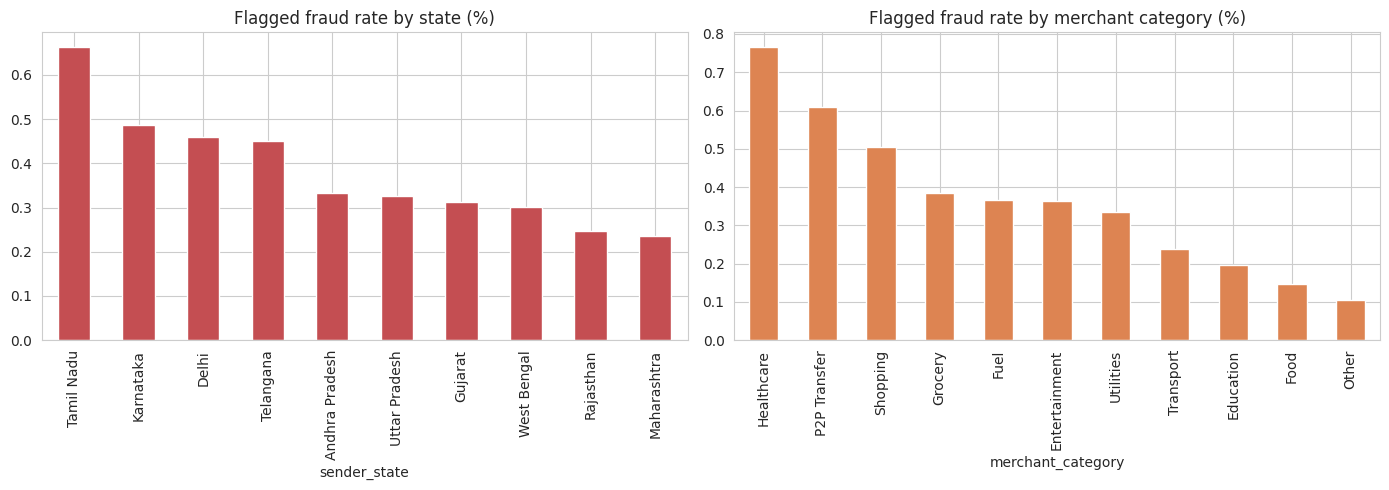

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
region_risk["flagged_rate_pct"].plot(kind="bar", ax=axes[0], color="#C44E52")
axes[0].set_title("Flagged fraud rate by state (%)")
category_risk["flagged_rate_pct"].plot(kind="bar", ax=axes[1], color="#DD8452")
axes[1].set_title("Flagged fraud rate by merchant category (%)")
plt.tight_layout()
plt.show()

## 9. Save the trained model

Saving the XGBoost model using its own native JSON format rather than a plain pickle -- ran into a corrupted-pickle issue earlier when moving the model file between machines (via a OneDrive-synced folder), and the native format avoids that entirely. Scaler and encoders are still fine as regular pickles.

In [25]:
xgb.save_model("xgb_fraud_model.json")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(encoders, "label_encoders.pkl")
with open("best_threshold.json", "w") as f:
    json.dump({"threshold": float(best_thresh), "feature_cols": feature_cols}, f, indent=2)

print("saved: xgb_fraud_model.json, scaler.pkl, label_encoders.pkl, best_threshold.json")

saved: xgb_fraud_model.json, scaler.pkl, label_encoders.pkl, best_threshold.json


## 10. Wrap-up

XGBoost with the tuned threshold ends up the clear winner -- ~86% precision and 50% recall, which is a realistic result for a rare-event problem like this rather than something suspiciously perfect. The feature importance plot backs up that the model is learning genuine behavioural fraud signals (device switching, odd-hour activity) instead of overfitting to artifacts of the synthetic data.

Things I'd try next if I had more time / a real dataset:
- account age / history length as a feature (new accounts making large transactions are riskier than old ones doing the same thing)
- device fingerprinting or IP/geolocation data, which real fraud systems rely on heavily and this dataset doesn't have
- a two-tier system -- auto-block above a very high confidence threshold, send medium-confidence scores to a human review queue instead of a single binary cutoff